<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_synchronization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D11_ENTRAINMENT — Coupled Oscillation Synchronization

Status

Working prototype target.

Purpose

This notebook demonstrates phase synchronization between two oscillating field cells.

Previous experiments:

D7_POSITION_GRADIENT created spatial addresses.

D8_BOUNDARY_SPLIT created bounded topological cells.

D9_OSCILLATION_CLOCK created a local oscillation clock.

D10_MEMORY_HOLD created a bounded memory cell.

This experiment tests whether two D9 oscillation cells can synchronize through weak coupling.

Core Idea

A single oscillator gives local time.

Two coupled oscillators can create shared time.

D11 answers:

can two field clocks align their rhythm?

Expected Result

The system should show:

- two oscillators with different initial phases
- weak coupling between them
- gradual phase alignment
- reduced frequency difference
- shared oscillation rhythm

Diffusion Alphabet Mapping

Symbol:

D11_ENTRAINMENT

Family:

Synchronization / Communication / Phase Locking

Meaning:

Two oscillating field cells synchronize their rhythm through weak coupling.

Repository Name

notebooks/diffusion_synchronization.ipynb

Experiment Label

Experiment 09 — Coupled Field Clock Synchronization

Commit Message

Add coupled oscillation synchronization prototype

STATE: PHASE_LOCKED
final phase error: 0.475
final phase std: 0.0
final frequency diff: 0.0


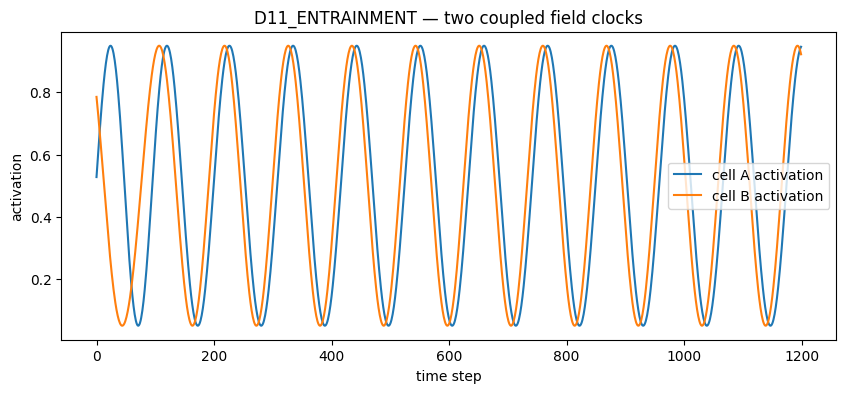

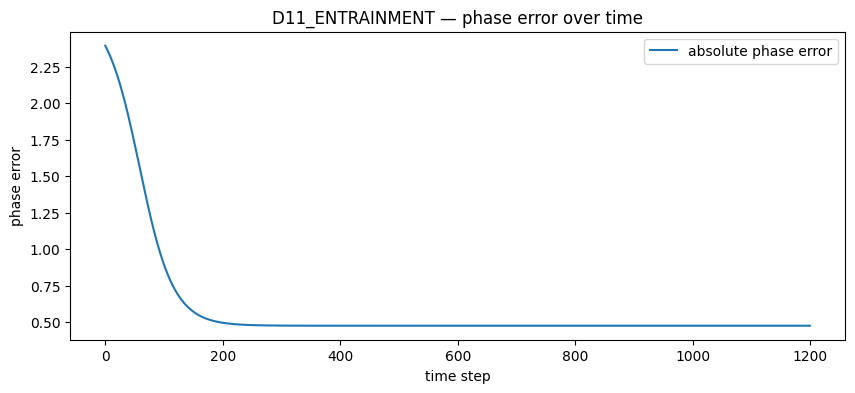

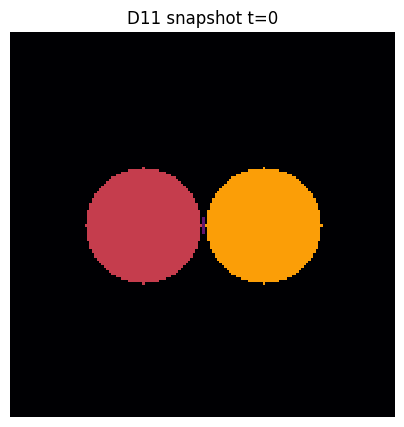

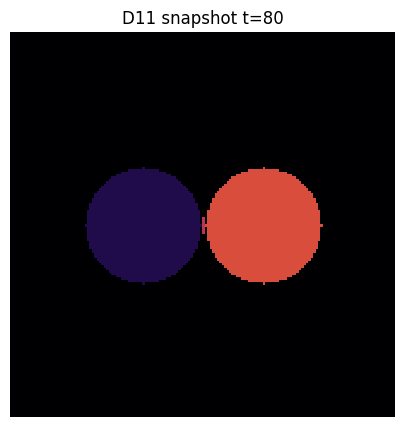

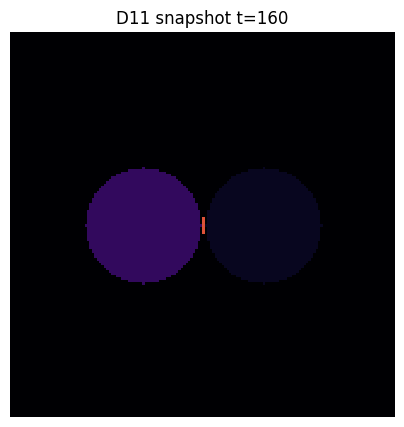

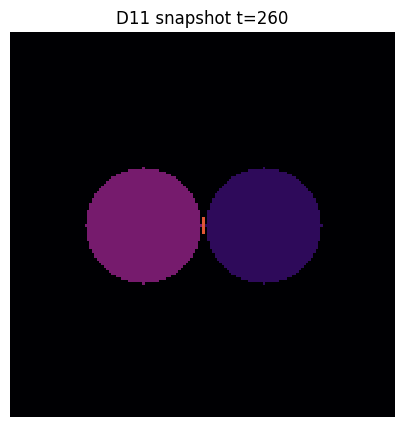

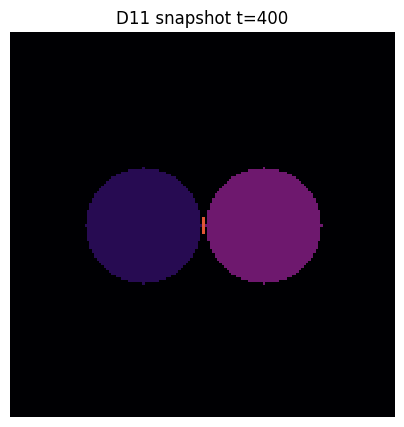

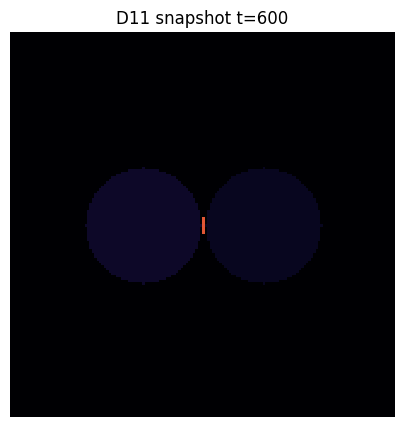

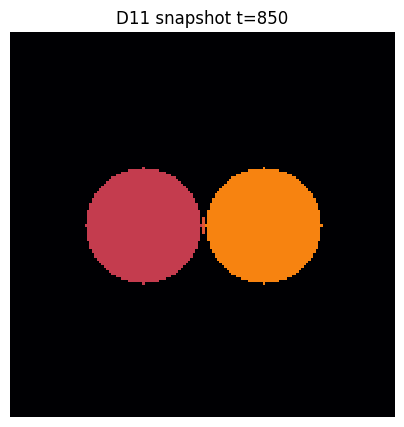

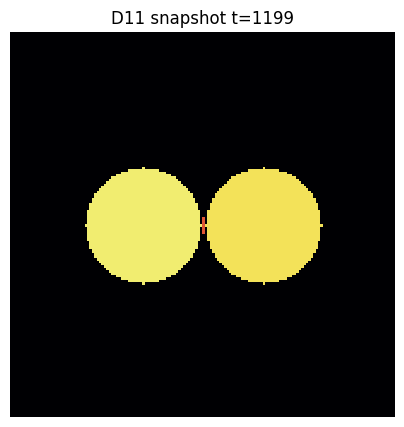

,STATE,RESULT,FINAL_PHASE_ERROR,FINAL_PHASE_STD,FINAL_FREQ_DIFF,COUPLING,OMEGA_A,OMEGA_B
0,D11_ENTRAINMENT,PHASE_LOCKED,0.475,0.0,0.0,0.35,1.0,1.32


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def wrap_angle(x):
    return np.angle(np.exp(1j * x))


def make_two_cell_masks(size=160, radius=24):
    Y, X = np.ogrid[:size, :size]

    center_a = (55, size // 2)
    center_b = (105, size // 2)

    dist_a = np.sqrt((X - center_a[0]) ** 2 + (Y - center_a[1]) ** 2)
    dist_b = np.sqrt((X - center_b[0]) ** 2 + (Y - center_b[1]) ** 2)

    cell_a = dist_a <= radius
    cell_b = dist_b <= radius

    bridge = (
        (Y >= size // 2 - 3)
        & (Y <= size // 2 + 3)
        & (X > center_a[0] + radius)
        & (X < center_b[0] - radius)
    )

    return cell_a, cell_b, bridge, center_a, center_b


def render_two_oscillator_field(
    size,
    cell_a,
    cell_b,
    bridge,
    activation_a,
    activation_b,
    phase_error,
):
    field = np.zeros((size, size), dtype=float)

    field[cell_a] = activation_a
    field[cell_b] = activation_b

    # Bridge brightness increases as phase difference becomes smaller.
    bridge_strength = 0.15 + 0.55 * (1 - abs(phase_error) / np.pi)
    bridge_strength = float(np.clip(bridge_strength, 0, 1))

    field[bridge] = bridge_strength

    return field


def run_coupled_oscillators(
    size=160,
    steps=1200,
    dt=0.05,
    omega_a=1.00,
    omega_b=1.32,
    coupling=0.35,
    initial_phase_a=0.0,
    initial_phase_b=2.4,
):
    """
    D11_ENTRAINMENT

    Two phase oscillators start with different phase and frequency.
    Weak coupling gradually phase-locks them.

    This is a compact phase-level model of two D9 field clocks.
    """

    cell_a, cell_b, bridge, center_a, center_b = make_two_cell_masks(size=size)

    theta_a = initial_phase_a
    theta_b = initial_phase_b

    history = []
    snapshots = {}

    for t in range(steps):
        phase_error = wrap_angle(theta_b - theta_a)

        dtheta_a = omega_a + coupling * np.sin(theta_b - theta_a)
        dtheta_b = omega_b + coupling * np.sin(theta_a - theta_b)

        theta_a += dt * dtheta_a
        theta_b += dt * dtheta_b

        activation_a = 0.5 + 0.45 * np.sin(theta_a)
        activation_b = 0.5 + 0.45 * np.sin(theta_b)

        phase_error = wrap_angle(theta_b - theta_a)

        field = render_two_oscillator_field(
            size=size,
            cell_a=cell_a,
            cell_b=cell_b,
            bridge=bridge,
            activation_a=activation_a,
            activation_b=activation_b,
            phase_error=phase_error,
        )

        history.append(
            {
                "t": t,
                "theta_a": theta_a,
                "theta_b": theta_b,
                "activation_a": activation_a,
                "activation_b": activation_b,
                "phase_error": phase_error,
                "abs_phase_error": abs(phase_error),
            }
        )

        if t in [0, 80, 160, 260, 400, 600, 850, steps - 1]:
            snapshots[t] = field.copy()

    history = pd.DataFrame(history)

    theta_a_unwrapped = np.unwrap(history["theta_a"].values)
    theta_b_unwrapped = np.unwrap(history["theta_b"].values)

    freq_a = np.diff(theta_a_unwrapped)
    freq_b = np.diff(theta_b_unwrapped)

    final_window = 250

    final_freq_diff = float(
        abs(freq_a[-final_window:].mean() - freq_b[-final_window:].mean())
    )

    final_phase_error = float(abs(history["phase_error"].iloc[-1]))
    final_phase_std = float(history["phase_error"].iloc[-final_window:].std())

    if final_freq_diff < 0.002 and final_phase_std < 0.03:
        result = "PHASE_LOCKED"
    else:
        result = "NOT_LOCKED"

    summary = pd.DataFrame(
        [
            {
                "STATE": "D11_ENTRAINMENT",
                "RESULT": result,
                "FINAL_PHASE_ERROR": round(final_phase_error, 3),
                "FINAL_PHASE_STD": round(final_phase_std, 3),
                "FINAL_FREQ_DIFF": round(final_freq_diff, 6),
                "COUPLING": coupling,
                "OMEGA_A": omega_a,
                "OMEGA_B": omega_b,
            }
        ]
    )

    return history, snapshots, summary


history, snapshots, summary = run_coupled_oscillators()

print("STATE:", summary["RESULT"].iloc[0])
print("final phase error:", summary["FINAL_PHASE_ERROR"].iloc[0])
print("final phase std:", summary["FINAL_PHASE_STD"].iloc[0])
print("final frequency diff:", summary["FINAL_FREQ_DIFF"].iloc[0])

plt.figure(figsize=(10, 4))
plt.plot(history["t"], history["activation_a"], label="cell A activation")
plt.plot(history["t"], history["activation_b"], label="cell B activation")
plt.title("D11_ENTRAINMENT — two coupled field clocks")
plt.xlabel("time step")
plt.ylabel("activation")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["t"], history["abs_phase_error"], label="absolute phase error")
plt.title("D11_ENTRAINMENT — phase error over time")
plt.xlabel("time step")
plt.ylabel("phase error")
plt.legend()
plt.show()

for t, snap in snapshots.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(snap, cmap="inferno", vmin=0, vmax=1, interpolation="nearest")
    plt.title(f"D11 snapshot t={t}")
    plt.axis("off")
    plt.show()

summary